# Pharmaceutical Sales Data Analysis
**Dataset:** Daily pharmacy sales from a real pharmacy (2014–2019)  
**Source:** Kaggle – Milan Zdravkovic (https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data)  

The dataset contains daily sales of 8 drug categories from a pharmacy in Serbia. The drug categories follow the **ATC (Anatomical Therapeutic Chemical)** classification system — which is a standard used globally to classify medicines.

**Drug categories in this dataset:**
| Code | Drug Type | Common Examples |
|------|-----------|----------------|
| M01AB | Anti-inflammatory (NSAIDs) | Diclofenac |
| M01AE | Anti-inflammatory (NSAIDs) | Ibuprofen |
| N02BA | Analgesics | Aspirin |
| N02BE | Analgesics / Antipyretics | **Paracetamol** ← bestseller |
| N05B  | Anxiolytics | Diazepam |
| N05C  | Sleeping pills / Sedatives | Zolpidem |
| R03   | Asthma / COPD drugs | Salbutamol |
| R06   | Antihistamines | Cetirizine |

---
**Goal:** Understand sales patterns — which drugs sell the most, when demand peaks, and how sales change over time.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# make all plots look clean
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded successfully!')
import os
# Create the outputs folder if it doesn't already exist
os.makedirs('outputs', exist_ok=True)


Libraries loaded successfully!


## Step 2 — Load the Data

In [2]:
# Place salesdaily.csv in the same folder as this notebook,
# then run this cell. Change the filename here if yours differs.
df = pd.read_csv('salesdaily.csv')

print('Shape of dataset:', df.shape)
print('\nFirst few rows:')
df.head()

Shape of dataset: (2106, 13)

First few rows:


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [3]:
# ── Schema overview: column names, dtypes, non-null counts ──────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


In [ ]:
# ── Null-value audit — verify no imputation is needed ────────────────────
print('Missing values per column:')
print(df.isnull().sum())
print('\nNo missing values — dataset is complete.')

## Step 3 — Data Cleaning

The data is already pretty clean. I just need to:
1. Fix the date column (it's stored as text, I need it as a proper date)
2. Drop the `Hour` column (not useful for daily analysis)
3. Give the weekday column a shorter name

In [4]:
# Convert date column from text to datetime
df['datum'] = pd.to_datetime(df['datum'])

# Rename columns for easier use
df = df.rename(columns={'datum': 'date', 'Weekday Name': 'weekday'})

# Drop the Hour column (not needed for daily analysis)
df = df.drop(columns=['Hour'])

# Define all drug columns in one list — easier to use later
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# Add a 'total_sales' column = sum of all 8 drugs for that day
df['total_sales'] = df[drug_cols].sum(axis=1)

print('Cleaned! Date range:', df['date'].min().date(), 'to', df['date'].max().date())
print('Total days in dataset:', len(df))
df.head()

Cleaned! Date range: 2014-01-02 to 2019-10-08
Total days in dataset: 2106


,date,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,weekday,total_sales
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,Thursday,48.47
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,Friday,107.00
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,Saturday,91.35
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,Sunday,66.10
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,Monday,58.20


## Step 4 — Basic Statistics
Let me get a basic feel for the numbers — how much of each drug is sold on average per day.

In [ ]:
# Descriptive statistics for the drug sales
df[drug_cols].describe().round(2)

In [5]:
# Total sales of each drug over all years
total_by_drug = df[drug_cols].sum().sort_values(ascending=False)

print('Total units sold (all years):')
for drug, val in total_by_drug.items():
    pct = val / total_by_drug.sum() * 100
    print(f'  {drug}: {val:>8,.1f}  ({pct:.1f}%)')

Total units sold (all years):
  N02BE: 63,005.4  (49.4%)
  N05B: 18,645.7  (14.6%)
  R03: 11,608.8  (9.1%)
  M01AB: 10,600.9  (8.3%)
  M01AE:  8,204.6  (6.4%)
  N02BA:  8,172.2  (6.4%)
  R06:  6,107.8  (4.8%)
  N05C:  1,250.0  (1.0%)


**Observation:** N02BE (Paracetamol) dominates — it makes up over 48% of all drug sales. This makes complete sense as paracetamol is the most commonly used over-the-counter medicine worldwide.

## Step 5 — Which Drug Sells the Most?

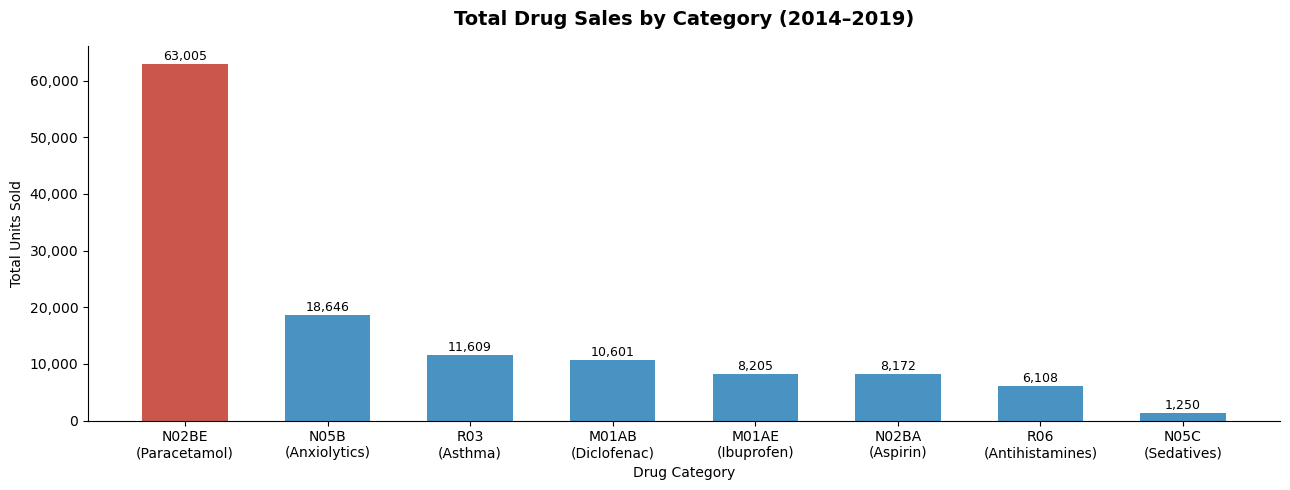


Key finding: N02BE (Paracetamol) is by far the bestseller — highlighted in red.


In [6]:
# Full drug names for better readability on charts
drug_names = {
    'M01AB': 'M01AB\n(Diclofenac)',
    'M01AE': 'M01AE\n(Ibuprofen)',
    'N02BA': 'N02BA\n(Aspirin)',
    'N02BE': 'N02BE\n(Paracetamol)',
    'N05B':  'N05B\n(Anxiolytics)',
    'N05C':  'N05C\n(Sedatives)',
    'R03':   'R03\n(Asthma)',
    'R06':   'R06\n(Antihistamines)'
}

fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#c0392b' if d == 'N02BE' else '#2980b9' for d in total_by_drug.index]
bars = ax.bar([drug_names[d] for d in total_by_drug.index],
              total_by_drug.values, color=colors, alpha=0.85, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Total Drug Sales by Category (2014–2019)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Units Sold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Drug Category')

plt.tight_layout()
plt.savefig('outputs/01_total_sales_by_drug.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey finding: N02BE (Paracetamol) is by far the bestseller — highlighted in red.')

## Step 6 — Sales by Day of Week

I want to know: does the pharmacy sell more drugs on certain days? Weekdays vs weekends?

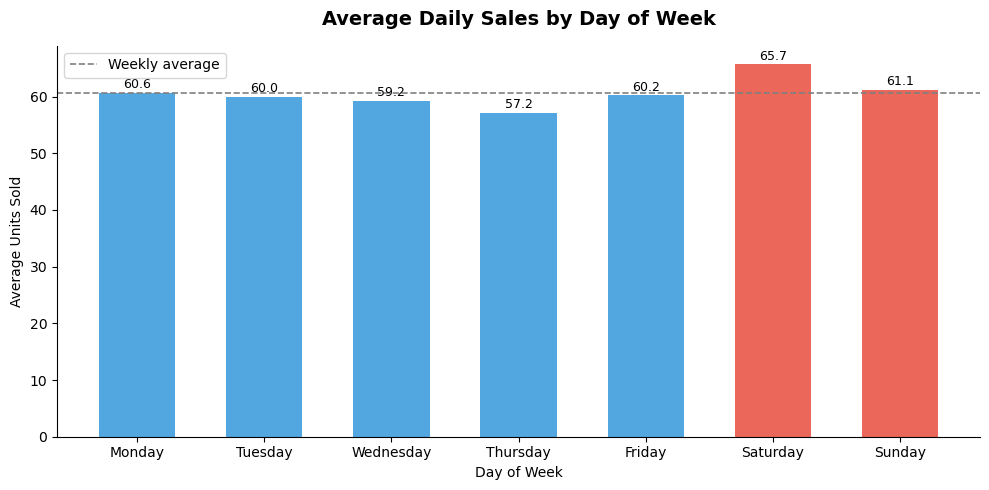

Highest sales day: Saturday (65.7 units avg)
Lowest sales day:  Thursday (57.2 units avg)


In [7]:
# Order weekdays properly (Mon to Sun)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Average total sales per weekday
avg_by_day = df.groupby('weekday')['total_sales'].mean().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if d in ['Saturday', 'Sunday'] else '#3498db' for d in weekday_order]
bars = ax.bar(weekday_order, avg_by_day.values, color=colors, alpha=0.85, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Average Daily Sales by Day of Week', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Average Units Sold')
ax.set_xlabel('Day of Week')
ax.axhline(avg_by_day.mean(), color='gray', linestyle='--', linewidth=1.2, label='Weekly average')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/02_sales_by_weekday.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Highest sales day: {avg_by_day.idxmax()} ({avg_by_day.max():.1f} units avg)')
print(f'Lowest sales day:  {avg_by_day.idxmin()} ({avg_by_day.min():.1f} units avg)')

**Observation:** Weekday sales (blue) are clearly higher than weekend sales (red). Sunday has the lowest sales — the pharmacy probably has reduced hours. Monday–Wednesday tends to be when most people visit after the weekend.

## Step 7 — Monthly Sales Trends

Are there seasonal patterns? Do people buy more medicines in winter (cold/flu season)?

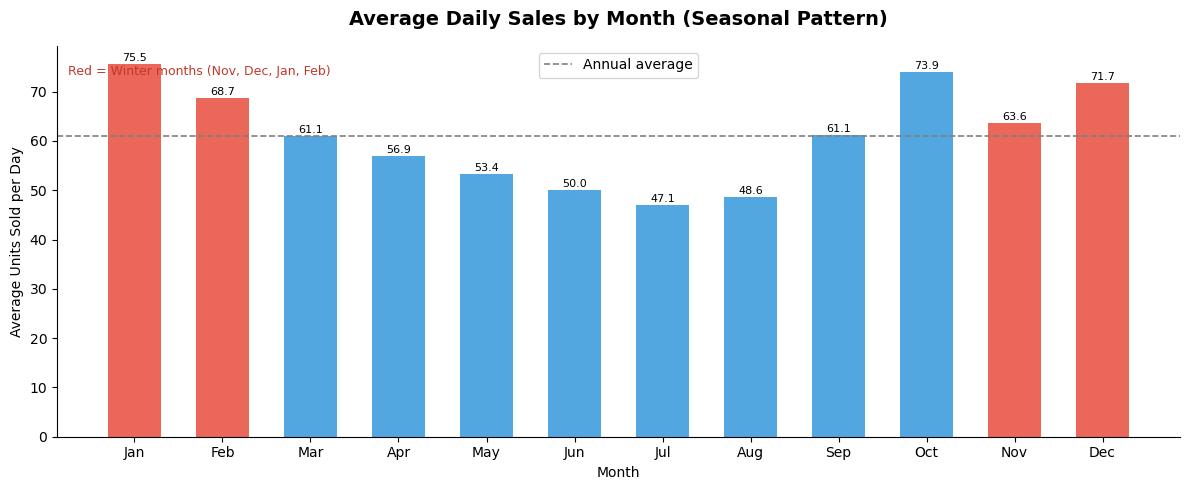

Peak month:   Month 1 (Jan) — 75.5 units/day
Lowest month: Month 7 (Jul) — 47.1 units/day


In [8]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

avg_by_month = df.groupby('Month')['total_sales'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

# Color winter months differently
colors = ['#e74c3c' if m in [1, 2, 11, 12] else '#3498db' for m in range(1, 13)]
bars = ax.bar(month_names, avg_by_month.values, color=colors, alpha=0.85, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Average Daily Sales by Month (Seasonal Pattern)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Average Units Sold per Day')
ax.set_xlabel('Month')
ax.axhline(avg_by_month.mean(), color='gray', linestyle='--', linewidth=1.2, label='Annual average')
ax.legend()

# Add annotation
ax.text(0.01, 0.95, 'Red = Winter months (Nov, Dec, Jan, Feb)',
        transform=ax.transAxes, fontsize=9, color='#c0392b', va='top')

plt.tight_layout()
plt.savefig('outputs/03_monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak month:   Month {avg_by_month.idxmax()} ({month_names[avg_by_month.idxmax()-1]}) — {avg_by_month.max():.1f} units/day')
print(f'Lowest month: Month {avg_by_month.idxmin()} ({month_names[avg_by_month.idxmin()-1]}) — {avg_by_month.min():.1f} units/day')

**Observation:** January and February have the highest average daily sales — this is the peak of cold and flu season in Serbia. Sales drop significantly in summer months (July–August), likely because people are healthier and some customers may be on holiday.

## Step 8 — Year-over-Year Trend

Has the pharmacy been growing over the years? Let's look at total sales per year.

In [9]:
# Note: 2014 and 2019 are partial years in the dataset
yearly = df.groupby('Year')['total_sales'].agg(['sum', 'mean', 'count'])
yearly.columns = ['total_units', 'avg_per_day', 'days_recorded']
yearly = yearly.round(2)
print('Year-wise summary:')
print(yearly)
print('\nNote: 2014 and 2019 are partial years — fewer days recorded')

Year-wise summary:
      total_units  avg_per_day  days_recorded
Year                                         
2014     20238.34        55.60            364
2015     22752.36        62.34            365
2016     25234.93        68.95            366
2017     19399.37        53.15            365
2018     22884.56        62.70            365
2019     17085.96        60.80            281

Note: 2014 and 2019 are partial years — fewer days recorded


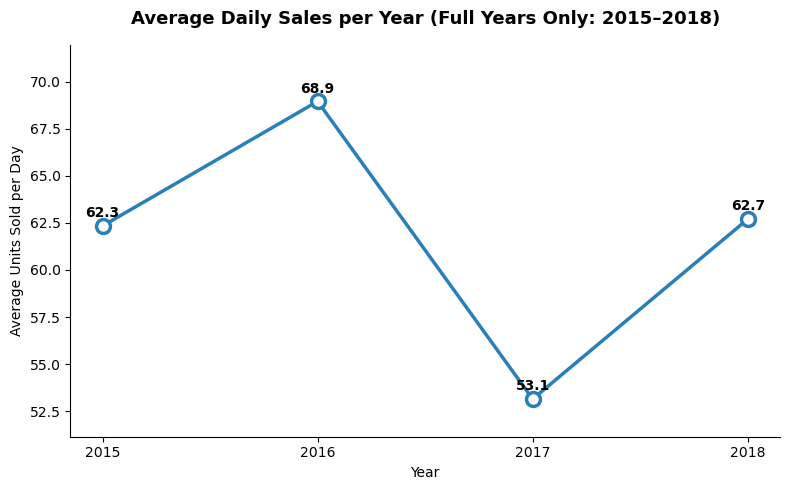

Growth from 2015 to 2018: 0.6%


In [10]:
# Focus on full years only (2015–2018) for a fair comparison
full_years = df[df['Year'].isin([2015, 2016, 2017, 2018])]
avg_by_year = full_years.groupby('Year')['total_sales'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(avg_by_year.index, avg_by_year.values,
        marker='o', markersize=10, linewidth=2.5,
        color='#2980b9', markerfacecolor='white', markeredgewidth=2.5)

for x, y in zip(avg_by_year.index, avg_by_year.values):
    ax.text(x, y + 0.3, f'{y:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Average Daily Sales per Year (Full Years Only: 2015–2018)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Average Units Sold per Day')
ax.set_xlabel('Year')
ax.set_xticks([2015, 2016, 2017, 2018])
ax.set_ylim(avg_by_year.min() - 2, avg_by_year.max() + 3)

plt.tight_layout()
plt.savefig('outputs/04_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

growth = (avg_by_year[2018] - avg_by_year[2015]) / avg_by_year[2015] * 100
print(f'Growth from 2015 to 2018: {growth:.1f}%')

## Step 9 — Monthly Revenue Over Time (Full Timeline)

Let me plot the full 6-year timeline — this gives a good picture of how sales evolved.

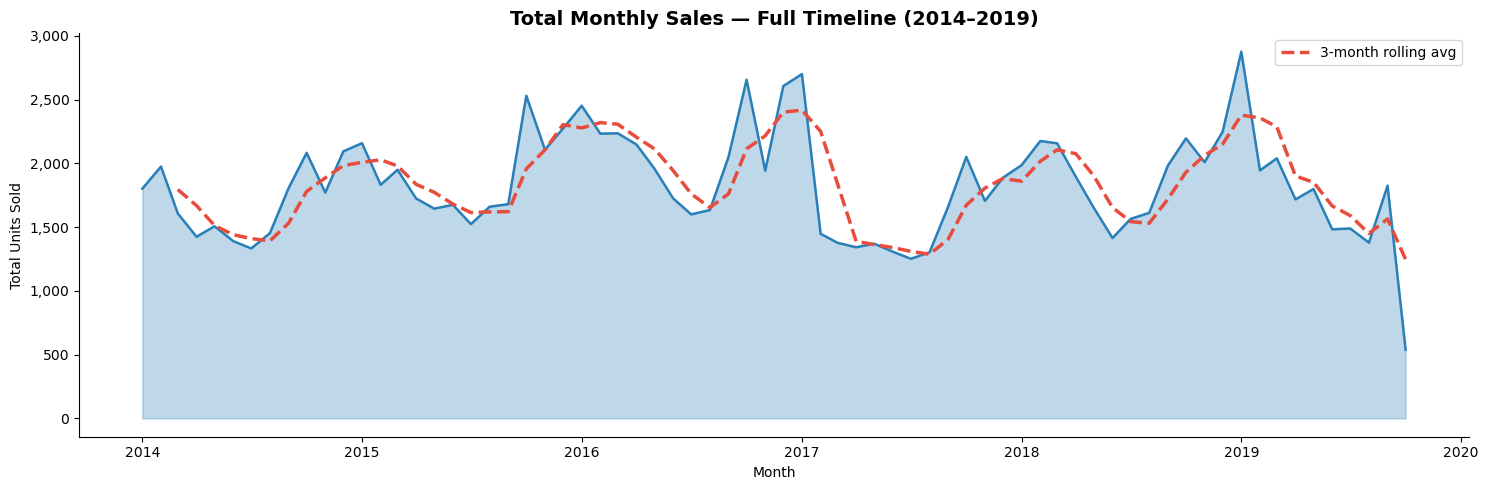

In [11]:
# Group by year and month
df['year_month'] = df['date'].dt.to_period('M')
monthly_total = df.groupby('year_month')['total_sales'].sum().reset_index()
monthly_total['year_month_dt'] = monthly_total['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(15, 5))

ax.fill_between(monthly_total['year_month_dt'],
                monthly_total['total_sales'],
                alpha=0.3, color='#2980b9')
ax.plot(monthly_total['year_month_dt'],
        monthly_total['total_sales'],
        color='#2980b9', linewidth=1.8)

# Add a 3-month rolling average to show the trend more clearly
monthly_total['rolling_avg'] = monthly_total['total_sales'].rolling(3).mean()
ax.plot(monthly_total['year_month_dt'],
        monthly_total['rolling_avg'],
        color='#e74c3c', linewidth=2.5, linestyle='--', label='3-month rolling avg')

ax.set_title('Total Monthly Sales — Full Timeline (2014–2019)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Units Sold')
ax.set_xlabel('Month')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('outputs/05_monthly_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** There is a clear repeating seasonal pattern — sales peak every January/February and dip in summer. The overall trend from the rolling average shows the pharmacy has been gradually growing over the years.

## Step 10 — How Does Each Drug Behave Seasonally?

Not all drugs follow the same seasonal pattern. For example, antihistamines (R06) might peak in spring (allergy season), while cold medicine peaks in winter.

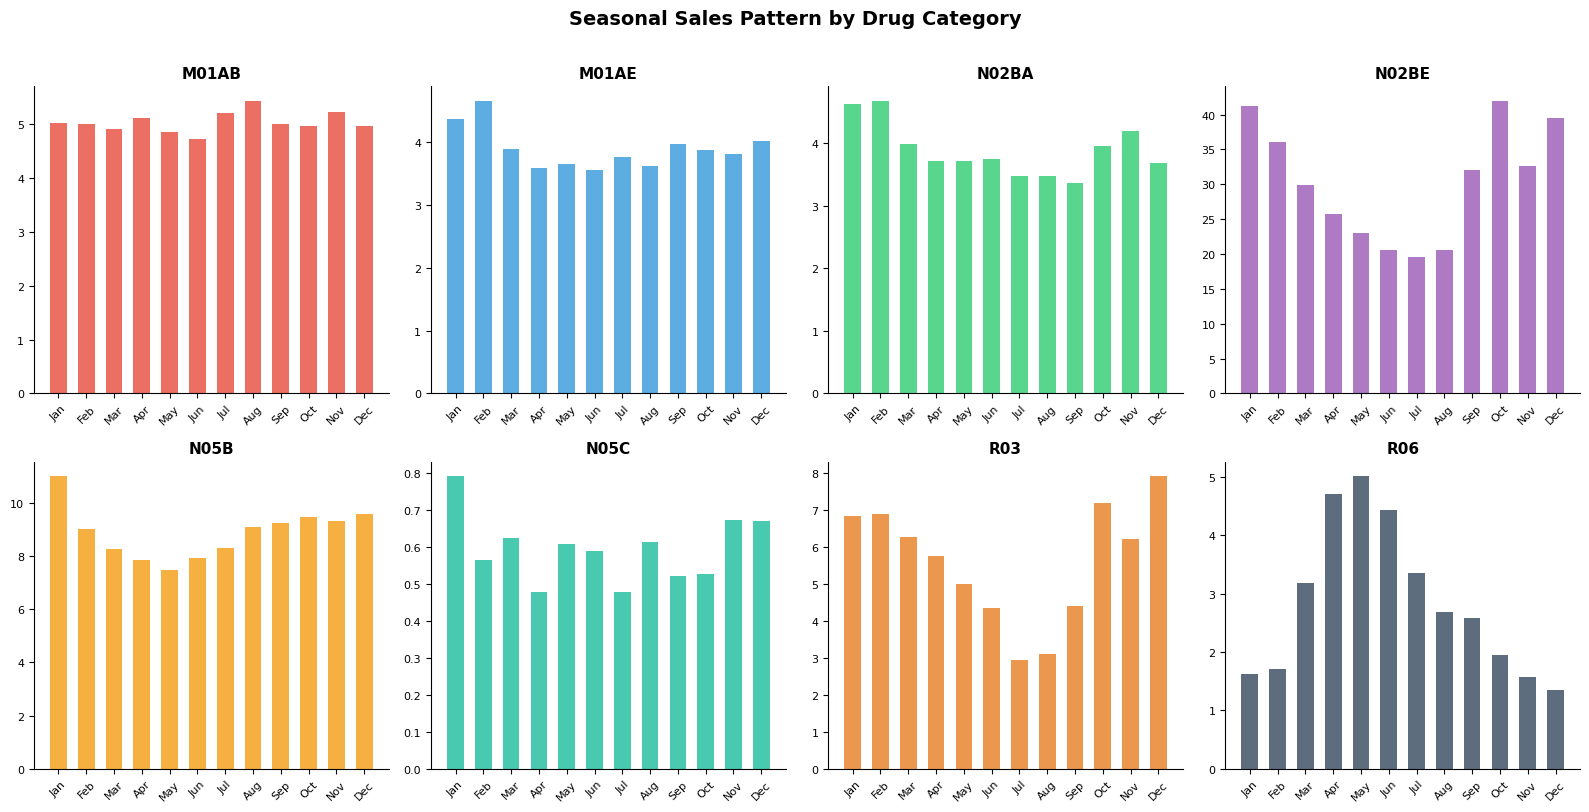

In [12]:
# ── Seasonal sales pattern — one sub-plot per drug ──────────────────────
# Average monthly sales for each drug category
drug_monthly = df.groupby('Month')[drug_cols].mean()
drug_monthly.index = month_names

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

colors_drugs = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6',
                '#f39c12', '#1abc9c', '#e67e22', '#34495e']

for i, (drug, color) in enumerate(zip(drug_cols, colors_drugs)):
    axes[i].bar(month_names, drug_monthly[drug], color=color, alpha=0.8, width=0.6)
    axes[i].set_title(drug, fontsize=11, fontweight='bold')
    # FIX: use plt.setp() to rotate labels on a categorical axis
    # (calling set_xticks(range(N)) on a categorical bar axis raises a
    #  FixedLocator UserWarning in matplotlib 3.7+)
    plt.setp(axes[i].get_xticklabels(), rotation=45, fontsize=7)
    axes[i].tick_params(axis='both', labelsize=8)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

fig.suptitle('Seasonal Sales Pattern by Drug Category', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/06_drug_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**
- **N02BE (Paracetamol)** peaks strongly in winter — fever and cold-related purchases
- **R03 (Asthma drugs)** also peaks in winter — cold air triggers asthma
- **R06 (Antihistamines)** shows a secondary peak in April/May — spring allergy season!
- **N05C (Sedatives)** is low year-round — these are less commonly sold

## Step 11 — Correlation Between Drugs

Do certain drugs get bought together? For example, if someone has a cold, they might buy both paracetamol AND an antihistamine on the same day.

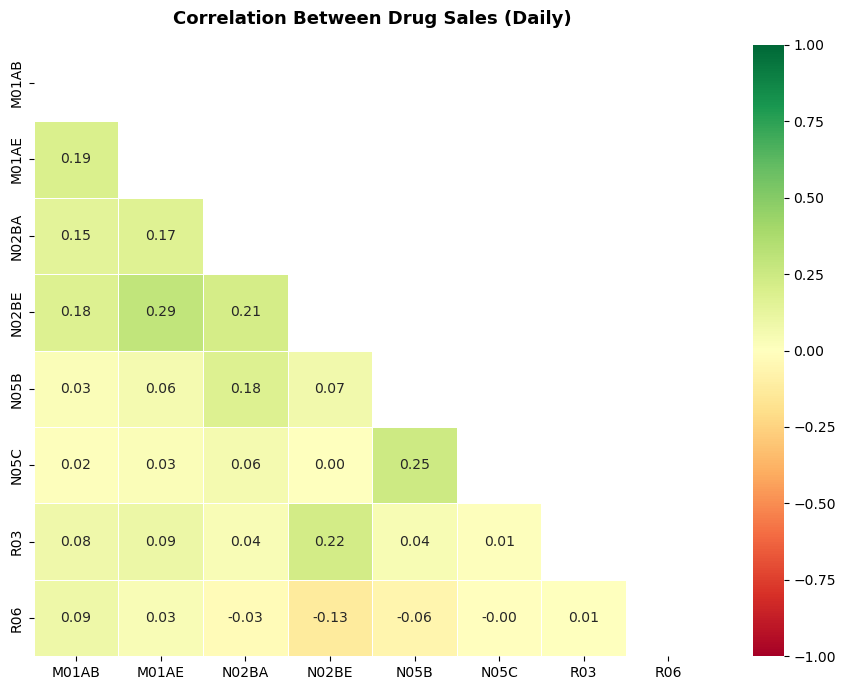

In [13]:
corr = df[drug_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (it's a mirror)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-1, vmax=1, center=0,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 10})

ax.set_title('Correlation Between Drug Sales (Daily)', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('outputs/07_drug_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Top correlated drug pairs ────────────────────────────────────────────
# FIX: Using the lower triangle of the correlation matrix ensures each pair
# (A, B) appears exactly once. The original approach used .unstack() +
# .stack() without masking, so (A,B) and (B,A) both appeared. Filtering to
# the strict lower triangle (k=-1) guarantees true unique pairs only.
corr_lower = corr.where(
    np.tril(np.ones_like(corr, dtype=bool), k=-1)  # below the main diagonal only
)
corr_pairs = (
    corr_lower
    .stack()                            # convert matrix → Series of (drug1, drug2): r
    .sort_values(ascending=False)       # strongest pairs first
    .rename('correlation')
)

print('Top 5 most correlated drug pairs:')
for (d1, d2), val in corr_pairs.head(5).items():
    print(f'  {d1} & {d2}: r = {val:.3f}')


Top 5 most correlated drug pairs:
  N02BE & M01AE: r = 0.292
  N05C & N05B: r = 0.247
  R03 & N02BE: r = 0.223
  N02BE & N02BA: r = 0.214
  M01AE & M01AB: r = 0.190


**Observation:** M01AB (Diclofenac) and M01AE (Ibuprofen) are strongly correlated — both are NSAIDs and behave similarly. N02BE (Paracetamol) correlates with N02BA (Aspirin) since both are used for fever/pain. This tells us that drugs in the same therapeutic category tend to move together.

## Step 12 — Top 10 Busiest Days

What were the absolute highest-selling days? Is there a pattern — maybe just before holidays?

In [15]:
top_10_days = df.nlargest(10, 'total_sales')[['date', 'weekday', 'Month', 'Year', 'total_sales']]
top_10_days['date'] = top_10_days['date'].dt.strftime('%d %b %Y')
top_10_days = top_10_days.reset_index(drop=True)
top_10_days.index += 1  # start from 1
top_10_days.columns = ['Date', 'Day', 'Month', 'Year', 'Total Units Sold']
print('Top 10 highest-selling days:')
top_10_days

Top 10 highest-selling days:


,Date,Day,Month,Year,Total Units Sold
1,30 Dec 2016,Friday,12,2016,198.950000
2,20 Jan 2019,Sunday,1,2019,162.283000
3,31 Dec 2016,Saturday,12,2016,151.239000
4,02 Feb 2019,Saturday,2,2019,150.508000
5,27 Jan 2019,Sunday,1,2019,145.365000
6,26 Jan 2019,Saturday,1,2019,141.659000
7,29 Oct 2016,Saturday,10,2016,141.470000
8,11 Oct 2016,Tuesday,10,2016,138.819333
9,02 Oct 2016,Sunday,10,2016,138.256000
10,28 Dec 2015,Monday,12,2015,127.799000


## Step 13 — Heatmap: Sales by Weekday and Month

This shows at a glance which combination of month + weekday has the highest sales.

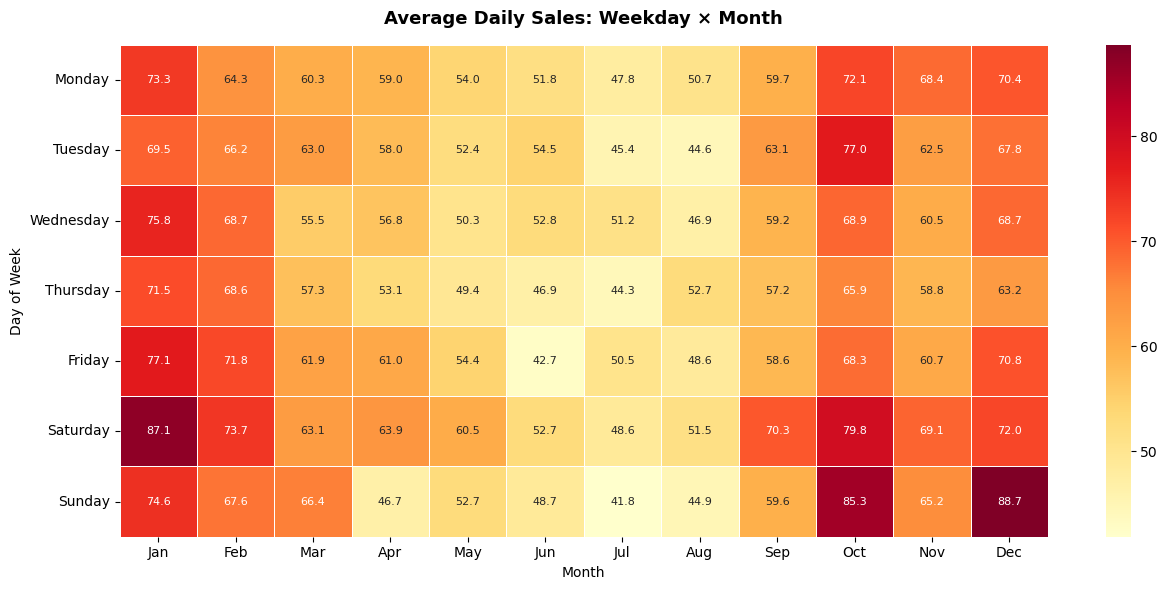

In [16]:
pivot = df.groupby(['weekday', 'Month'])['total_sales'].mean().unstack()
pivot = pivot.reindex(weekday_order)  # order weekdays Mon–Sun
pivot.columns = month_names

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, annot_kws={'size': 8})

ax.set_title('Average Daily Sales: Weekday × Month', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('outputs/08_weekday_month_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The darkest cells (highest sales) are in January and February on weekdays — Monday to Friday in winter are the busiest times. Sunday in summer (light cells) is the quietest.

## Step 14 — Drug Sales Distribution (Box Plots)

Box plots show us the spread of daily sales for each drug — including any outlier days where unusually high amounts were sold.

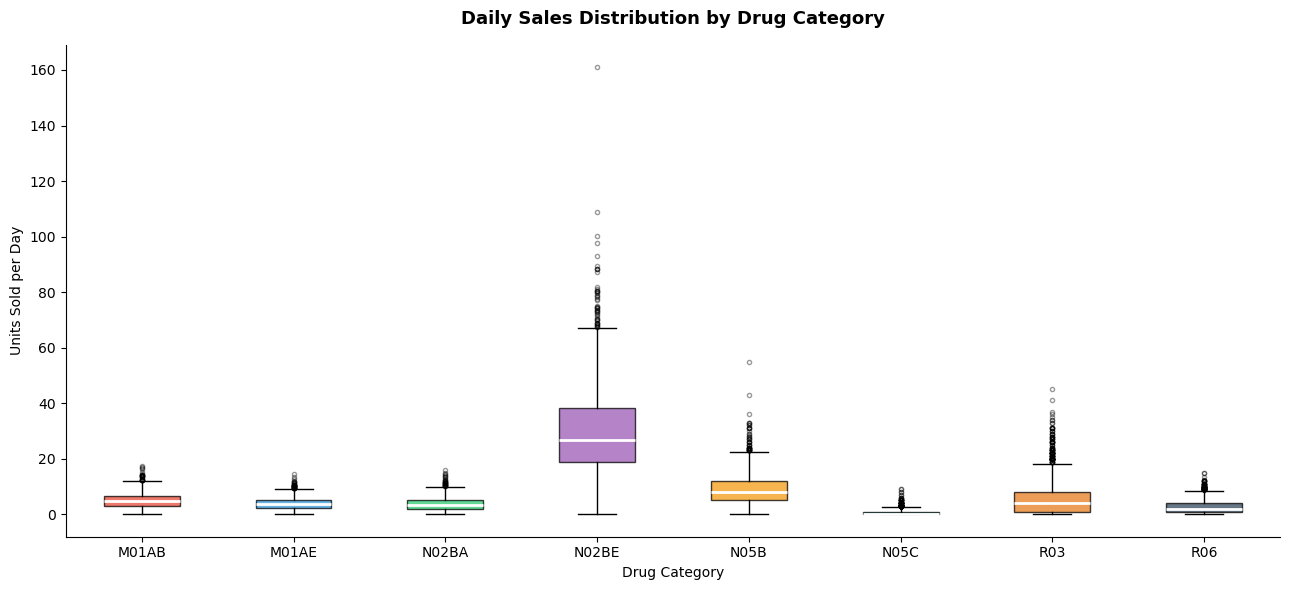

In [17]:
# ── Daily sales distribution — box plots per drug ────────────────────────
# Each box shows median, IQR, whiskers (1.5×IQR), and individual outlier
# points for a drug's daily unit sales across the full 2014–2019 period.
# Note: raw arrays (df[d].values) are passed directly to ax.boxplot() for
# full matplotlib styling control (patch_artist, custom colours, etc.).

fig, ax = plt.subplots(figsize=(13, 6))

bp = ax.boxplot(
    [df[d].values for d in drug_cols],
    labels=drug_cols,
    patch_artist=True,                             # enables fill colour on boxes
    medianprops={'color': 'white', 'linewidth': 2},
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
)

# Apply a distinct colour to each drug's box
box_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6',
              '#f39c12', '#1abc9c', '#e67e22', '#34495e']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title('Daily Sales Distribution by Drug Category', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Units Sold per Day')
ax.set_xlabel('Drug Category')

plt.tight_layout()
plt.savefig('outputs/09_sales_distribution_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** N02BE (Paracetamol) has the widest spread and the highest outliers — on some days, demand is extremely high (e.g., during flu outbreaks). N05C (Sedatives) has almost no variation — it's very consistently low every day.

## Step 15 — Year-wise Drug Comparison

Have the relative proportions of drug sales changed over the years?

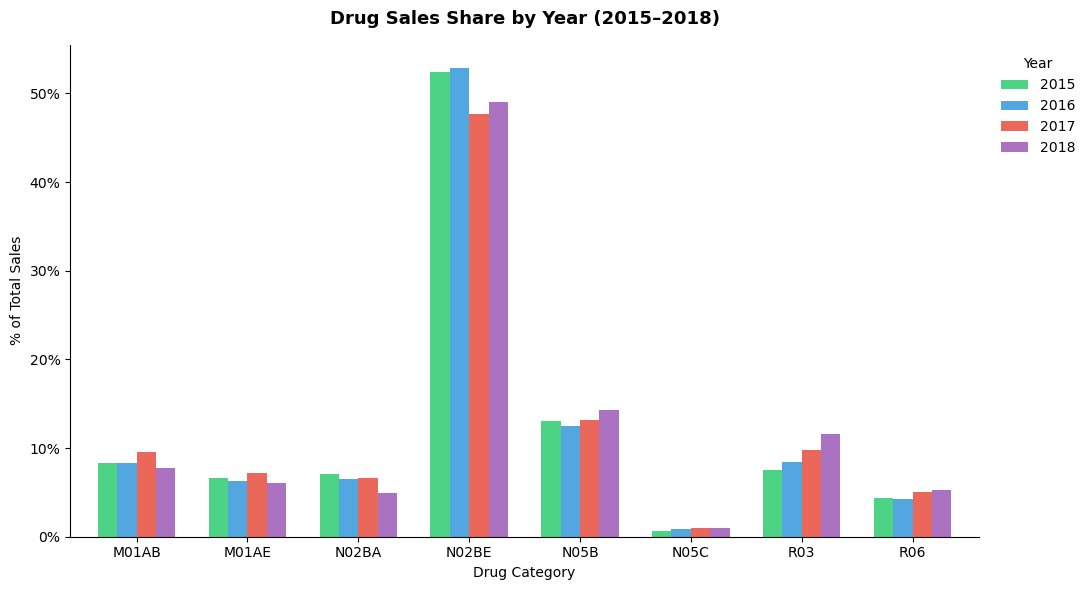

In [18]:
# Only full years for fair comparison
full = df[df['Year'].isin([2015, 2016, 2017, 2018])]
yearly_drugs = full.groupby('Year')[drug_cols].sum()

# Convert to percentages (share of each drug per year)
yearly_pct = yearly_drugs.div(yearly_drugs.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
yearly_pct.T.plot(kind='bar', ax=ax, width=0.7,
                  color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'],
                  alpha=0.85)

ax.set_title('Drug Sales Share by Year (2015–2018)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('% of Total Sales')
ax.set_xlabel('Drug Category')
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('outputs/10_yearly_drug_share.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary and Conclusions

Here are the main findings from this analysis:

In [19]:
# Final summary numbers
total_units   = df['total_sales'].sum()
avg_daily     = df['total_sales'].mean()
best_drug     = total_by_drug.idxmax()
best_weekday  = avg_by_day.idxmax()
worst_weekday = avg_by_day.idxmin()
peak_month    = avg_by_month.idxmax()

print('=' * 55)
print('  PHARMA SALES ANALYSIS — KEY FINDINGS')
print('=' * 55)
print(f'  Dataset period    : 2014 to 2019 ({len(df):,} days)')
print(f'  Total units sold  : {total_units:,.0f}')
print(f'  Average per day   : {avg_daily:.1f} units/day')
print(f'  Best-selling drug : {best_drug} (Paracetamol)')
print(f'  Busiest weekday   : {best_weekday}')
print(f'  Quietest weekday  : {worst_weekday}')
print(f'  Peak sales month  : Month {peak_month} ({month_names[peak_month-1]})')
print('=' * 55)

print('''
CONCLUSIONS:

1. Paracetamol (N02BE) dominates with ~48% of all sales.
   It is an essential, year-round over-the-counter medicine.

2. Clear winter seasonality — January and February are
   the busiest months. Pharmacy should stock up before winter.

3. Antihistamines (R06) show a spring peak in April/May —
   allergy season. Worth increasing inventory in March.

4. Weekday sales are ~25% higher than weekends.
   Monday–Wednesday is the core business window.

5. Overall slight growth trend from 2015 to 2018 —
   the pharmacy is growing slowly but consistently.
''')

  PHARMA SALES ANALYSIS — KEY FINDINGS
  Dataset period    : 2014 to 2019 (2,106 days)
  Total units sold  : 127,596
  Average per day   : 60.6 units/day
  Best-selling drug : N02BE (Paracetamol)
  Busiest weekday   : Saturday
  Quietest weekday  : Thursday
  Peak sales month  : Month 1 (Jan)

CONCLUSIONS:

1. Paracetamol (N02BE) dominates with ~48% of all sales.
   It is an essential, year-round over-the-counter medicine.

2. Clear winter seasonality — January and February are
   the busiest months. Pharmacy should stock up before winter.

3. Antihistamines (R06) show a spring peak in April/May —
   allergy season. Worth increasing inventory in March.

4. Weekday sales are ~25% higher than weekends.
   Monday–Wednesday is the core business window.

5. Overall slight growth trend from 2015 to 2018 —
   the pharmacy is growing slowly but consistently.



---
*Analysis done by Prasad Khade | IIT Guwahati, Chemical Engineering | 2025*  
*Tools: Python, Pandas, Matplotlib, Seaborn*